In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.eda import load_data, validate_data

In [2]:
df = load_data()
df

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,no,no,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   state                   2666 non-null   category
 1   account_length          2666 non-null   int64   
 2   area_code               2666 non-null   category
 3   international_plan      2666 non-null   category
 4   voice_mail_plan         2666 non-null   category
 5   number_vmail_messages   2666 non-null   int64   
 6   total_day_minutes       2666 non-null   float64 
 7   total_day_calls         2666 non-null   int64   
 8   total_day_charge        2666 non-null   float64 
 9   total_eve_minutes       2666 non-null   float64 
 10  total_eve_calls         2666 non-null   int64   
 11  total_eve_charge        2666 non-null   float64 
 12  total_night_minutes     2666 non-null   float64 
 13  total_night_calls       2666 non-null   int64   
 14  total_night_charge      2666 non-nu

In [4]:
validate_data(df)

'Data is valid'

In [5]:
def null_values(df):
	n_nulls = df.isnull().sum().sum() # number of null values
	print(f"Dataset contains {n_nulls} null values.")

null_values(df)

Dataset contains 0 null values.


In [6]:
def get_duplicates(df):
	n_exact_dups = df.duplicated().sum() # duplicate rows
	print(f"Dataset contains {n_exact_dups} exact duplicates")

get_duplicates(df)

Dataset contains 0 exact duplicates


We are dealing with a imbalanced dataset, so we need to do some data understanding to understand the data better.

In [7]:
df['churn'].value_counts() # churn imbalance

churn
False    2278
True      388
Name: count, dtype: int64

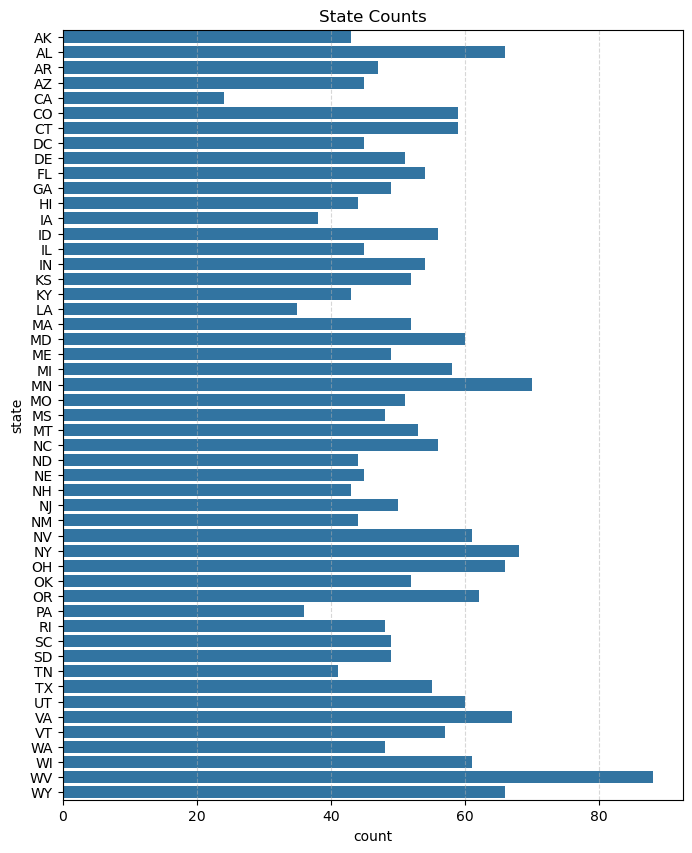

In [8]:
def plot_states(df):
	# plot the state counts
	states_sorted = pd.DataFrame(df['state'].value_counts().sort_values(ascending=False)).reset_index()

	_, ax = plt.subplots(figsize=(8, 10))

	sns.barplot(
		data=states_sorted,
		y='state',
		x='count',
		ax=ax
	)
	ax.set_title('State Counts')
	ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plot_states(df)

Statistic,Value
Count,"2,666.000"
Missing,0.000
Unique,205.000
Mean,100.620
Median,100.000
Std. Dev.,39.564
Variance,"1,565.308"
Min,1.000
Q1 (25%),73.000
Q3 (75%),127.000


Statistic,Value
Count,"2,666.000"
Missing,0.000
Unique,205.000
Mean,100.620
Median,100.000
Std. Dev.,39.564
Variance,"1,565.308"
Min,1.000
Q1 (25%),73.000
Q3 (75%),127.000


,Statistic,Value
0,Count,"2,666.000"
1,Missing,0.000
2,Unique,205.000
3,Mean,100.620
4,Median,100.000
5,Std. Dev.,39.564
6,Variance,"1,565.308"
7,Min,1.000
8,Q1 (25%),73.000
9,Q3 (75%),127.000


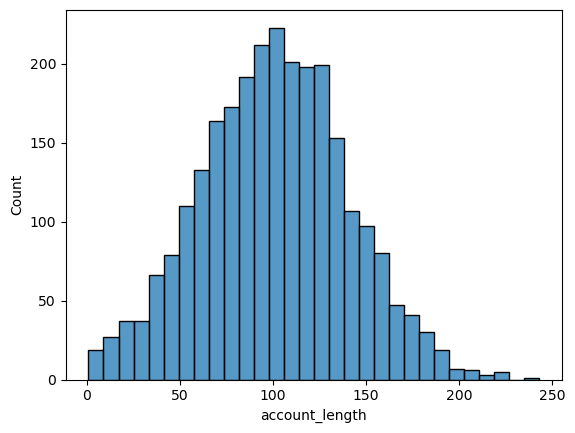

In [9]:
sns.histplot(
    data=df,
    x="account_length",
    bins=30,
)
import pandas as pd
from IPython.display import display


def describe_stats(
    df: pd.DataFrame,
    feature: str,
    *,
    decimals: int = 3,
) -> pd.DataFrame:
    """
    Generate a compact statistical summary for a numeric feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    feature : str
        Name of the numeric feature to summarize.
    decimals : int, default=3
        Number of decimal places for numeric results.

    Returns
    -------
    pd.DataFrame
        Formatted statistical summary.
    """

    # -------------------------
    # 1. Validate input
    # -------------------------
    if feature not in df.columns:
        raise KeyError(f"Feature '{feature}' not found in DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[feature]):
        raise TypeError(
            f"Feature '{feature}' must be numeric. "
            f"Found dtype: {df[feature].dtype}"
        )

    # -------------------------
    # 2. Extract feature
    # -------------------------
    s = df[feature]

    # -------------------------
    # 3. Calculate statistics
    # -------------------------
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    stats = {
        "Count": s.count(),
        "Missing": s.isna().sum(),
        "Unique": s.nunique(),

        "Mean": s.mean(),
        "Median": s.median(),
        "Std. Dev.": s.std(),
        "Variance": s.var(),

        "Min": s.min(),
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "Max": s.max(),

        "Range": s.max() - s.min(),
        "IQR": q3 - q1,

        "Skewness": s.skew(),
        "Kurtosis": s.kurt(),
    }

    # -------------------------
    # 4. Convert to table
    # -------------------------
    result = pd.DataFrame(
        {
            "Statistic": stats.keys(),
            "Value": stats.values(),
        }
    )

    # -------------------------
    # 5. Format output
    # -------------------------
    result["Value"] = result["Value"].apply(
        lambda x: (
            f"{x:,.{decimals}f}"
            if isinstance(x, (float, int))
            else x
        )
    )

    # -------------------------
    # 6. Display
    # -------------------------
    display(result.style.hide(axis="index"))

    return result

describe_stats(df, "account_length")

describe_stats(df, "account_length")

In [16]:
import pandas as pd
from IPython.display import display


def describe_stats(
    df: pd.DataFrame,
    feature: str,
    *,
    decimals: int = 3,
) -> pd.DataFrame:
    """
    Generate a compact statistical summary for a numeric feature.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    feature : str
        Name of the numeric feature to summarize.
    decimals : int, default=3
        Number of decimal places for numeric results.

    Returns
    -------
    pd.DataFrame
        Formatted statistical summary.
    """

    # -------------------------
    # 1. Validate input
    # -------------------------
    if feature not in df.columns:
        raise KeyError(f"Feature '{feature}' not found in DataFrame.")

    if not pd.api.types.is_numeric_dtype(df[feature]):
        raise TypeError(
            f"Feature '{feature}' must be numeric. "
            f"Found dtype: {df[feature].dtype}"
        )

    # -------------------------
    # 2. Extract feature
    # -------------------------
    s = df[feature]

    # -------------------------
    # 3. Calculate statistics
    # -------------------------
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    stats = {
        "Count": s.count(),
        "Missing": s.isna().sum(),
        "Unique": s.nunique(),

        "Mean": s.mean(),
        "Median": s.median(),
        "Std. Dev.": s.std(),
        "Variance": s.var(),

        "Min": s.min(),
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "Max": s.max(),

        "Range": s.max() - s.min(),
        "IQR": q3 - q1,

        "Skewness": s.skew(),
        "Kurtosis": s.kurt(),
    }

    # -------------------------
    # 4. Convert to table
    # -------------------------
    result = pd.DataFrame(
        {
            "Statistic": stats.keys(),
            "Value": stats.values(),
        }
    )

    # -------------------------
    # 5. Format output
    # -------------------------
    result["Value"] = result["Value"].apply(
        lambda x: (
            f"{x:,.{decimals}f}"
            if isinstance(x, (float, int))
            else x
        )
    )

    # -------------------------
    # 6. Display
    # -------------------------
    # display(result.style.hide(axis="index"))

    return result.set_index("Statistic")

describe_stats(df, "account_length")

,Value
Statistic,
Count,"2,666.000"
Missing,0.000
Unique,205.000
Mean,100.620
Median,100.000
Std. Dev.,39.564
Variance,"1,565.308"
Min,1.000
Q1 (25%),73.000
